# Stochastic Volatility — Basic Model

This notebook demonstrates the complete stochastic volatility pipeline:

1. **Exploratory analysis** of financial returns
2. **Particle filtering** of the latent log-volatility $h_t$
3. **Parameter estimation** via Particle Marginal Metropolis–Hastings (PMMH)
4. **Volatility forecasting** $h$-steps ahead

The model is:
$$y_t = \exp(h_t/2)\,\varepsilon_t, \qquad h_{t+1} = \mu + \phi\,(h_t - \mu) + \sigma\,\eta_t$$
where $\varepsilon_t, \eta_t \sim N(0,1)$ independently.

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from scipy import stats
from dataclasses import dataclass
import time

# Add project root to path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))

from particlefilterbox.models.stochastic_volatility import StochasticVolatility
from particlefilterbox.pmcmc import PMMH

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

## 1. Data Loading

We use synthetic daily S&P 500 returns calibrated to realistic volatility levels.

In [2]:
data_path = os.path.join('..', 'data', 'sp500_returns.csv')
df = pd.read_csv(data_path)
print(f'Loaded {len(df)} observations')
print(df.head())

# Use first 500 observations for speed
T_use = 500
returns = df['returns'].values[:T_use]
dates = pd.to_datetime(df['date'].values[:T_use])
print(f'Using first {T_use} observations')

Loaded 2500 observations
         date   returns
0  2014-01-02 -0.012365
1  2014-01-03  0.012260
2  2014-01-06 -0.014389
3  2014-01-07 -0.003294
4  2014-01-08 -0.009380
Using first 500 observations


## 2. Exploratory Analysis

Financial returns exhibit **volatility clustering**: large moves tend to follow large moves. The ACF of squared returns captures this persistence.

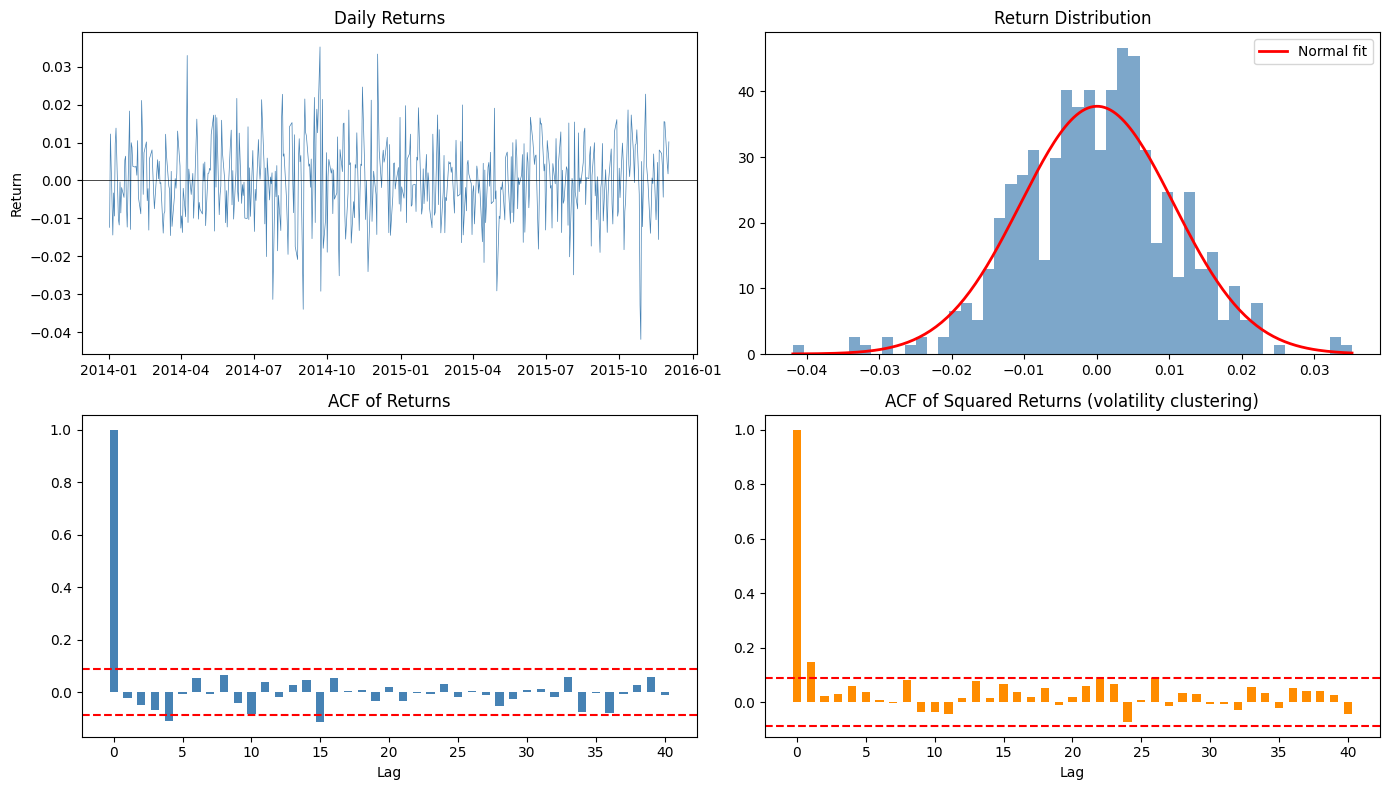

Kurtosis: 0.70 (excess, normal=0)
Skewness: -0.115
Mean: 0.000050, Std: 0.010571


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Returns time series
axes[0, 0].plot(dates, returns, linewidth=0.5, color='steelblue')
axes[0, 0].set_title('Daily Returns')
axes[0, 0].set_ylabel('Return')
axes[0, 0].axhline(0, color='k', linewidth=0.5)

# Histogram
axes[0, 1].hist(returns, bins=50, density=True, alpha=0.7, color='steelblue')
x_grid = np.linspace(returns.min(), returns.max(), 200)
axes[0, 1].plot(x_grid, stats.norm.pdf(x_grid, returns.mean(), returns.std()),
               'r-', linewidth=2, label='Normal fit')
axes[0, 1].set_title('Return Distribution')
axes[0, 1].legend()

# ACF of returns
max_lag = 40
acf_returns = np.array([
    np.corrcoef(returns[:-lag], returns[lag:])[0, 1] if lag > 0 else 1.0
    for lag in range(max_lag + 1)
])
axes[1, 0].bar(range(max_lag + 1), acf_returns, color='steelblue', width=0.6)
axes[1, 0].axhline(1.96 / np.sqrt(len(returns)), color='r', linestyle='--')
axes[1, 0].axhline(-1.96 / np.sqrt(len(returns)), color='r', linestyle='--')
axes[1, 0].set_title('ACF of Returns')
axes[1, 0].set_xlabel('Lag')

# ACF of squared returns
sq_returns = returns ** 2
acf_sq = np.array([
    np.corrcoef(sq_returns[:-lag], sq_returns[lag:])[0, 1] if lag > 0 else 1.0
    for lag in range(max_lag + 1)
])
axes[1, 1].bar(range(max_lag + 1), acf_sq, color='darkorange', width=0.6)
axes[1, 1].axhline(1.96 / np.sqrt(len(returns)), color='r', linestyle='--')
axes[1, 1].axhline(-1.96 / np.sqrt(len(returns)), color='r', linestyle='--')
axes[1, 1].set_title('ACF of Squared Returns (volatility clustering)')
axes[1, 1].set_xlabel('Lag')

plt.tight_layout()
plt.show()

print(f'Kurtosis: {stats.kurtosis(returns, fisher=True):.2f} (excess, normal=0)')
print(f'Skewness: {stats.skew(returns):.3f}')
print(f'Mean: {returns.mean():.6f}, Std: {returns.std():.6f}')

## 3. Particle Filtering of Latent Volatility

We define the basic SV model and run a **Bootstrap Particle Filter** with $N=1000$ particles to estimate the latent log-volatility path $\{h_t\}$.

In [4]:
# Define basic SV model
sv_model = StochasticVolatility(variant='basic')
print('Default parameters:', sv_model.params)
print(f'k_states={sv_model.k_states}, k_obs={sv_model.k_obs}')

# Bootstrap Particle Filter (vectorized)
def bootstrap_pf_sv(
    y: np.ndarray,
    mu: float, phi: float, sigma: float,
    n_particles: int = 1000,
    seed: int = 42,
) -> dict:
    """Run bootstrap PF on basic SV model. Returns filtered means, stds, and log-likelihood."""
    rng = np.random.default_rng(seed)
    T = len(y)
    
    # Stationary distribution
    var_stat = sigma**2 / (1.0 - phi**2)
    particles = rng.normal(mu, np.sqrt(var_stat), size=n_particles)
    
    filtered_means = np.zeros(T)
    filtered_stds = np.zeros(T)
    filtered_q05 = np.zeros(T)
    filtered_q95 = np.zeros(T)
    ess_history = np.zeros(T)
    log_lik = 0.0
    
    for t in range(T):
        # Weights
        vol = np.exp(particles / 2.0)
        log_w = -0.5 * np.log(2 * np.pi) - np.log(vol) - 0.5 * (y[t] / vol)**2
        max_lw = np.max(log_w)
        w = np.exp(log_w - max_lw)
        sw = np.sum(w)
        log_lik += max_lw + np.log(sw) - np.log(n_particles)
        w /= sw
        
        # Store
        filtered_means[t] = np.sum(w * particles)
        filtered_stds[t] = np.sqrt(np.sum(w * (particles - filtered_means[t])**2))
        
        # Weighted quantiles
        idx_sort = np.argsort(particles)
        cumw = np.cumsum(w[idx_sort])
        filtered_q05[t] = particles[idx_sort][np.searchsorted(cumw, 0.05)]
        filtered_q95[t] = particles[idx_sort][np.searchsorted(cumw, 0.95, side='right').clip(max=n_particles-1)]
        ess_history[t] = 1.0 / np.sum(w**2)
        
        # Resample and propagate
        idx = rng.choice(n_particles, size=n_particles, p=w)
        particles = particles[idx]
        particles = mu + phi * (particles - mu) + sigma * rng.standard_normal(n_particles)
    
    return {
        'means': filtered_means,
        'stds': filtered_stds,
        'q05': filtered_q05,
        'q95': filtered_q95,
        'ess': ess_history,
        'log_likelihood': log_lik,
    }

# Run with default parameters
t0 = time.time()
pf_result = bootstrap_pf_sv(
    returns, mu=-1.0, phi=0.97, sigma=0.15, n_particles=1000, seed=42
)
elapsed = time.time() - t0
print(f'Bootstrap PF completed in {elapsed:.2f}s')
print(f'Log-likelihood: {pf_result["log_likelihood"]:.2f}')
print(f'Mean ESS: {pf_result["ess"].mean():.0f} / 1000')

Default parameters: {'mu': -1.0, 'phi': 0.97, 'sigma': 0.15}
k_states=1, k_obs=1
Bootstrap PF completed in 0.09s
Log-likelihood: 680.26
Mean ESS: 945 / 1000


## 4. Filtered Volatility with Confidence Bands

We overlay the filtered volatility $\exp(h_t/2)$ on the absolute returns, with 90% posterior credible bands.

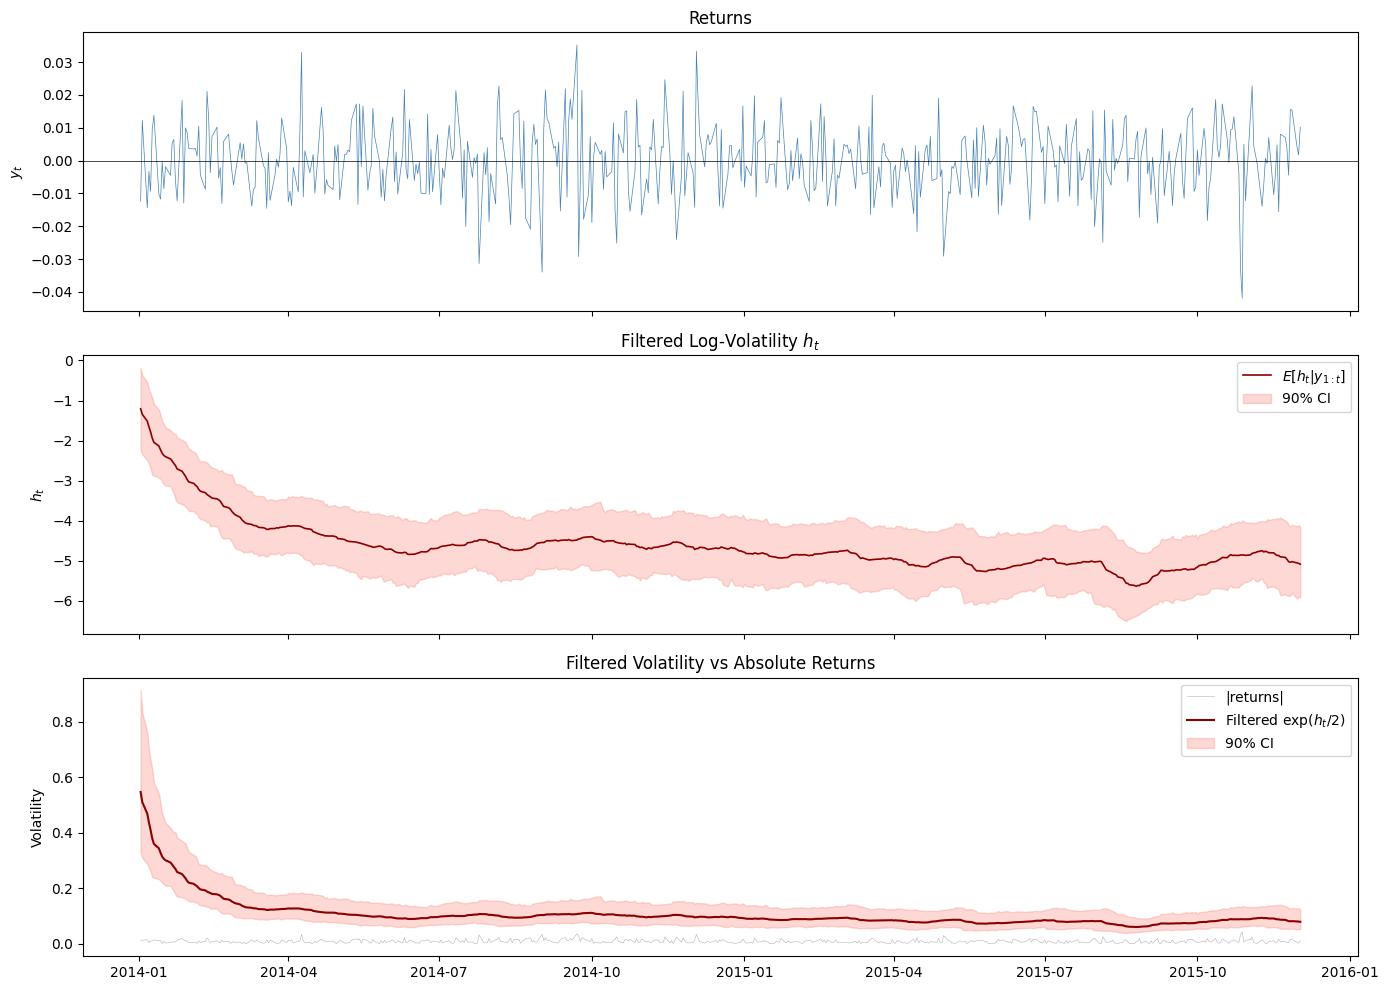

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1: Returns
axes[0].plot(dates, returns, linewidth=0.5, color='steelblue')
axes[0].set_title('Returns')
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].set_ylabel('$y_t$')

# Panel 2: Filtered log-volatility with bands
h_mean = pf_result['means']
h_q05 = pf_result['q05']
h_q95 = pf_result['q95']
axes[1].plot(dates, h_mean, color='darkred', linewidth=1.2, label='$E[h_t | y_{1:t}]$')
axes[1].fill_between(dates, h_q05, h_q95, alpha=0.3, color='salmon', label='90% CI')
axes[1].set_title('Filtered Log-Volatility $h_t$')
axes[1].set_ylabel('$h_t$')
axes[1].legend()

# Panel 3: Filtered volatility vs absolute returns
vol_mean = np.exp(h_mean / 2.0)
vol_q05 = np.exp(h_q05 / 2.0)
vol_q95 = np.exp(h_q95 / 2.0)
axes[2].plot(dates, np.abs(returns), linewidth=0.4, color='grey', alpha=0.6, label='|returns|')
axes[2].plot(dates, vol_mean, color='darkred', linewidth=1.5, label='Filtered $\\exp(h_t/2)$')
axes[2].fill_between(dates, vol_q05, vol_q95, alpha=0.3, color='salmon', label='90% CI')
axes[2].set_title('Filtered Volatility vs Absolute Returns')
axes[2].set_ylabel('Volatility')
axes[2].legend()

plt.tight_layout()
plt.show()

## 5. Parameter Estimation via PMMH

Particle Marginal Metropolis–Hastings uses the particle filter log-likelihood as an unbiased estimator inside a Metropolis–Hastings chain to sample from $p(\mu, \phi, \sigma \mid y_{1:T})$.

We run a short chain for demonstration.

In [6]:
# Model wrapper for PMMH
@dataclass
class FilterResult:
    log_likelihood: float
    filtered_means: np.ndarray | None = None

class SVModelWrapper:
    def __init__(self) -> None:
        self.sv = StochasticVolatility(variant='basic')
        self.param_names = list(self.sv.param_names)  # ['mu', 'phi', 'sigma']
        self._rng_internal = np.random.default_rng(0)

    def set_params(self, theta: np.ndarray) -> None:
        for i, name in enumerate(self.param_names):
            self.sv.params[name] = float(theta[i])

    def get_params(self) -> np.ndarray:
        return np.array([self.sv.params[n] for n in self.param_names])

    def filter(self, endog, n_particles=200, rng=None):
        if rng is None:
            rng = self._rng_internal
        T = len(endog)
        mu = self.sv.params['mu']
        phi = self.sv.params['phi']
        sigma = self.sv.params['sigma']
        if abs(phi) >= 1.0 or sigma <= 0:
            return FilterResult(log_likelihood=-np.inf)
        var_stat = sigma**2 / (1.0 - phi**2)
        particles = rng.normal(mu, np.sqrt(max(var_stat, 1e-10)), size=n_particles)
        log_lik = 0.0
        for t in range(T):
            vol = np.exp(particles / 2.0)
            log_w = -0.5 * np.log(2 * np.pi) - np.log(vol) - 0.5 * (endog[t] / vol)**2
            max_lw = np.max(log_w)
            w = np.exp(log_w - max_lw)
            sw = np.sum(w)
            if sw < 1e-300:
                return FilterResult(log_likelihood=-np.inf)
            log_lik += max_lw + np.log(sw) - np.log(n_particles)
            w /= sw
            idx = rng.choice(n_particles, size=n_particles, p=w)
            particles = particles[idx]
            particles = mu + phi * (particles - mu) + sigma * rng.standard_normal(n_particles)
        return FilterResult(log_likelihood=log_lik)

    def initial_sample(self, n, rng):
        mu, phi, sigma = self.sv.params['mu'], self.sv.params['phi'], self.sv.params['sigma']
        if abs(phi) >= 1.0 or sigma <= 0:
            return rng.standard_normal(n)
        return rng.normal(mu, np.sqrt(sigma**2 / (1.0 - phi**2)), size=n)

    def transition_sample(self, x_prev, rng):
        mu, phi, sigma = self.sv.params['mu'], self.sv.params['phi'], self.sv.params['sigma']
        return float(mu + phi * (float(x_prev) - mu) + sigma * rng.standard_normal())

    def transition_logpdf(self, x_new, x_old):
        mu, phi, sigma = self.sv.params['mu'], self.sv.params['phi'], self.sv.params['sigma']
        if sigma <= 0: return -np.inf
        return float(stats.norm.logpdf(float(x_new), loc=mu + phi * (float(x_old) - mu), scale=sigma))

    def observation_logpdf(self, y, x):
        h = float(x)
        vol = np.exp(h / 2.0)
        if vol < 1e-300: return -np.inf
        return float(-0.5 * np.log(2 * np.pi) - np.log(vol) - 0.5 * (float(y) / vol)**2)

# Prior
class SVPrior:
    def logpdf(self, theta):
        mu_val, phi_val, sig_val = theta[0], theta[1], theta[2]
        if not (0 < phi_val < 1) or sig_val <= 0:
            return -np.inf
        lp = float(stats.norm.logpdf(mu_val, loc=-1, scale=1))
        lp += float(stats.beta.logpdf(phi_val, 20, 1.5))
        lp += float(stats.invgamma.logpdf(sig_val, a=2.5, scale=0.025))
        return lp

    def sample(self, rng):
        mu_s = rng.normal(-1, 1)
        phi_s = float(stats.beta.rvs(20, 1.5, random_state=rng))
        sig_s = float(stats.invgamma.rvs(2.5, scale=0.025, random_state=rng))
        return np.array([mu_s, phi_s, sig_s])

    @property
    def cov(self):
        return np.array([1.0, 20*1.5/((21.5)**2*22.5), 0.025**2/(1.5**2*0.5)])

# Run PMMH
model_wrapper = SVModelWrapper()
prior = SVPrior()

# Use first 200 obs for fast demo
y_pmmh = returns[:200]

pmmh = PMMH(
    model=model_wrapper,
    prior=prior,
    n_particles=200,
    n_iterations=2000,
    proposal_cov='adaptive',
    target_acceptance=0.234,
    burnin=500,
    thin=1,
    seed=42,
)

print('Running PMMH (N=200, 2000 iterations)...')
t0 = time.time()
pmmh_results = pmmh.run(endog=y_pmmh, theta_init=np.array([-1.0, 0.97, 0.15]), verbose=500)
elapsed = time.time() - t0
print(f'Completed in {elapsed:.1f}s')
print(f'Acceptance rate: {pmmh_results.acceptance_rate():.3f}')
print(pmmh_results.summary())

Running PMMH (N=200, 2000 iterations)...


PMMH iteration 500/2000, acceptance rate (last 500): 0.180, loglik: 612.25


PMMH iteration 1000/2000, acceptance rate (last 500): 0.198, loglik: 613.84


PMMH iteration 1500/2000, acceptance rate (last 500): 0.218, loglik: 615.05


PMMH iteration 2000/2000, acceptance rate (last 500): 0.232, loglik: 614.16
Completed in 12.5s
Acceptance rate: 0.207
PMCMC Posterior Summary
Parameter             Mean        Std       2.5%        50%      97.5%      ESS
----------------------------------------------------------------------
mu                 -0.5750     0.1547    -0.8463    -0.5129    -0.3734      2.9
phi                 0.9995     0.0004     0.9986     0.9995     0.9999    124.7
sigma               0.1503     0.0080     0.1346     0.1523     0.1614      3.6
----------------------------------------------------------------------
Total iterations: 2000
Burn-in: 500
Thinning: 1
Effective samples: 1500
Acceptance rate: 0.2070


## 6. Posterior Distributions

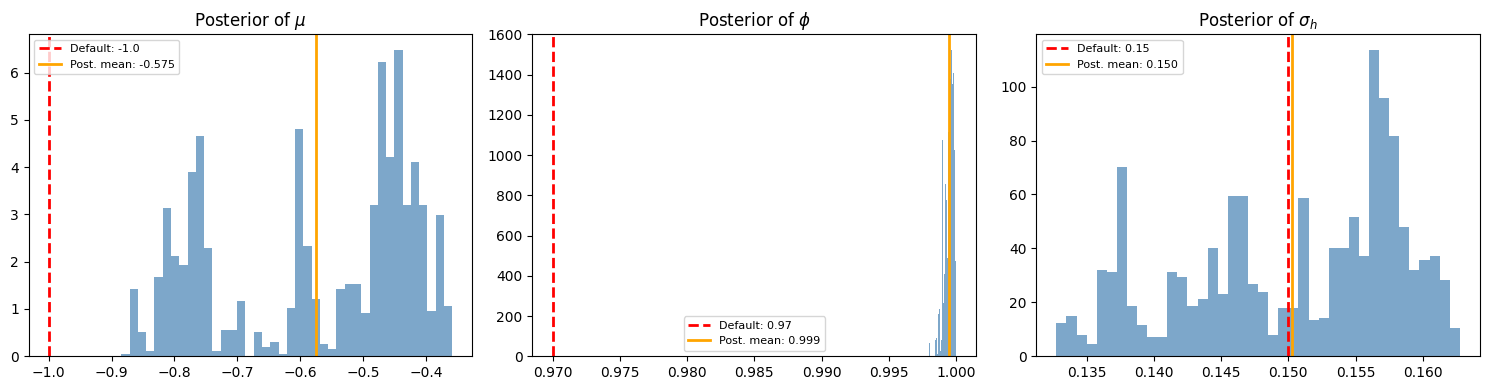

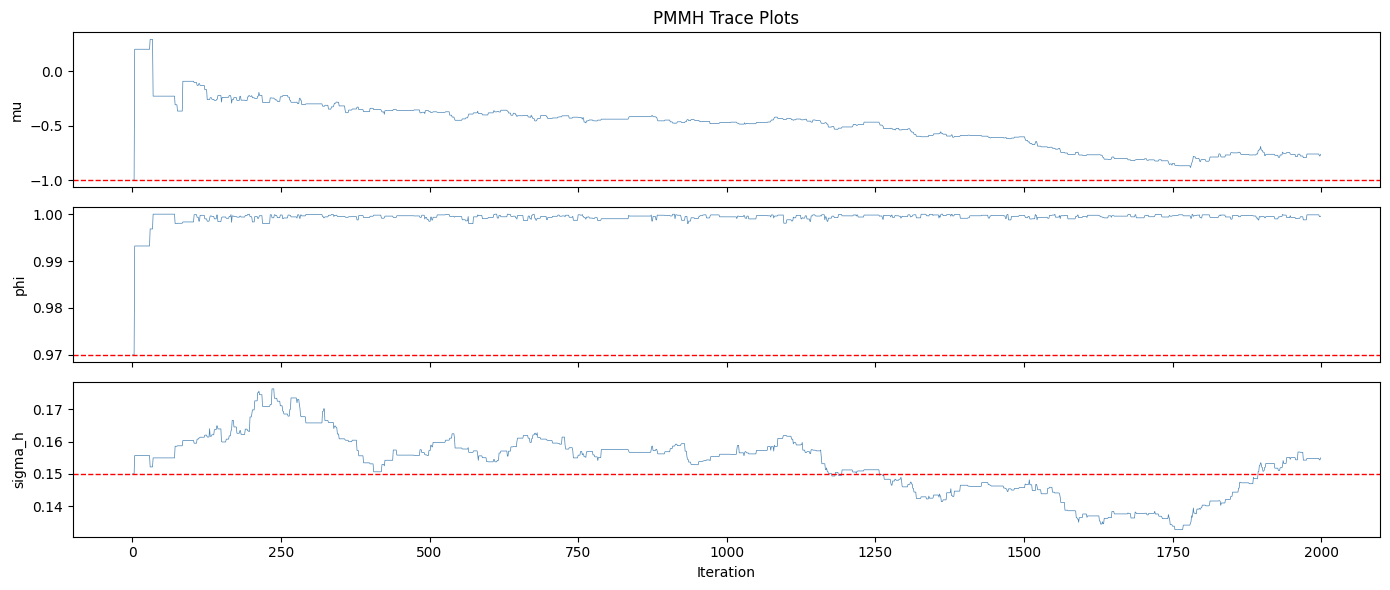

In [7]:
samples = pmmh_results.posterior_samples
param_names = ['$\\mu$', '$\\phi$', '$\\sigma_h$']
true_vals = [-1.0, 0.97, 0.15]  # defaults used for filtering

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (ax, name, true_v) in enumerate(zip(axes, param_names, true_vals)):
    ax.hist(samples[:, i], bins=40, density=True, alpha=0.7, color='steelblue')
    ax.axvline(true_v, color='red', linestyle='--', linewidth=2, label=f'Default: {true_v}')
    ax.axvline(samples[:, i].mean(), color='orange', linestyle='-', linewidth=2,
              label=f'Post. mean: {samples[:, i].mean():.3f}')
    ax.set_title(f'Posterior of {name}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Trace plots
fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
raw_names = ['mu', 'phi', 'sigma_h']
chains = pmmh_results.chains
for i, (ax, name) in enumerate(zip(axes, raw_names)):
    ax.plot(chains[:, i], linewidth=0.5, color='steelblue')
    ax.axhline(true_vals[i], color='red', linestyle='--', linewidth=1)
    ax.set_ylabel(name)
axes[-1].set_xlabel('Iteration')
axes[0].set_title('PMMH Trace Plots')
plt.tight_layout()
plt.show()

## 7. Volatility Forecasting

We forecast the log-volatility $h$-steps ahead by propagating particles forward from the last filtered distribution.

Posterior mean params: mu=-0.575, phi=0.999, sigma=0.150


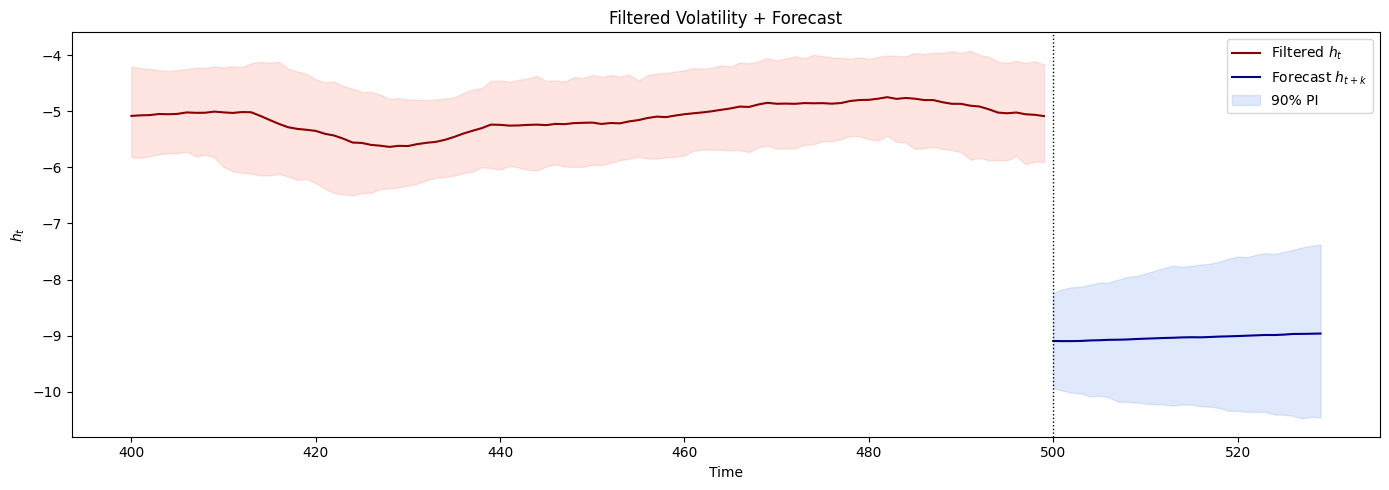

In [8]:
# Forecast using posterior mean parameters
post_mean = pmmh_results.posterior_mean()
mu_hat, phi_hat, sig_hat = post_mean[0], post_mean[1], post_mean[2]
print(f'Posterior mean params: mu={mu_hat:.3f}, phi={phi_hat:.3f}, sigma={sig_hat:.3f}')

# Re-run filter to get final particle cloud
rng_fc = np.random.default_rng(123)
N_fc = 2000
var_stat = sig_hat**2 / (1.0 - phi_hat**2)
particles_fc = rng_fc.normal(mu_hat, np.sqrt(max(var_stat, 1e-10)), size=N_fc)

for t in range(T_use):
    vol = np.exp(particles_fc / 2.0)
    log_w = -0.5 * np.log(2 * np.pi) - np.log(vol) - 0.5 * (returns[t] / vol)**2
    max_lw = np.max(log_w)
    w = np.exp(log_w - max_lw)
    w /= np.sum(w)
    idx = rng_fc.choice(N_fc, size=N_fc, p=w)
    particles_fc = particles_fc[idx]
    particles_fc = mu_hat + phi_hat * (particles_fc - mu_hat) + sig_hat * rng_fc.standard_normal(N_fc)

# Now forecast H steps ahead
H = 30
forecast_mean = np.zeros(H)
forecast_q05 = np.zeros(H)
forecast_q95 = np.zeros(H)
particles_ahead = particles_fc.copy()

for h in range(H):
    # Propagate one step without observations
    particles_ahead = mu_hat + phi_hat * (particles_ahead - mu_hat) + sig_hat * rng_fc.standard_normal(N_fc)
    forecast_mean[h] = np.mean(particles_ahead)
    forecast_q05[h] = np.percentile(particles_ahead, 5)
    forecast_q95[h] = np.percentile(particles_ahead, 95)

# Plot: filtered + forecast
fig, ax = plt.subplots(figsize=(14, 5))
n_show = 100
t_past = np.arange(T_use - n_show, T_use)
t_future = np.arange(T_use, T_use + H)

ax.plot(t_past, pf_result['means'][-n_show:], color='darkred', linewidth=1.5, label='Filtered $h_t$')
ax.fill_between(t_past, pf_result['q05'][-n_show:], pf_result['q95'][-n_show:],
                alpha=0.2, color='salmon')
ax.plot(t_future, forecast_mean, color='darkblue', linewidth=1.5, label='Forecast $h_{t+k}$')
ax.fill_between(t_future, forecast_q05, forecast_q95, alpha=0.2, color='cornflowerblue', label='90% PI')
ax.axvline(T_use, color='k', linestyle=':', linewidth=1)
ax.set_xlabel('Time')
ax.set_ylabel('$h_t$')
ax.set_title('Filtered Volatility + Forecast')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Parameter Summary

In [9]:
post_mean = pmmh_results.posterior_mean()
post_std = pmmh_results.posterior_std()
ci_low, ci_high = pmmh_results.credible_interval(alpha=0.05)

summary_df = pd.DataFrame({
    'Parameter': ['mu', 'phi', 'sigma_h'],
    'Default': [-1.0, 0.97, 0.15],
    'Posterior Mean': post_mean,
    'Posterior Std': post_std,
    '95% CI Low': ci_low,
    '95% CI High': ci_high,
    'ESS': [pmmh_results.effective_sample_size(i) for i in range(3)],
})
print(summary_df.to_string(index=False))
summary_df

Parameter  Default  Posterior Mean  Posterior Std  95% CI Low  95% CI High        ESS
       mu    -1.00       -0.575016       0.154727   -0.846286    -0.373354   2.926349
      phi     0.97        0.999452       0.000360    0.998633     0.999927 124.743635
  sigma_h     0.15        0.150283       0.008013    0.134572     0.161408   3.619602


,Parameter,Default,Posterior Mean,Posterior Std,95% CI Low,95% CI High,ESS
0,mu,-1.00,-0.575016,0.154727,-0.846286,-0.373354,2.926349
1,phi,0.97,0.999452,0.000360,0.998633,0.999927,124.743635
2,sigma_h,0.15,0.150283,0.008013,0.134572,0.161408,3.619602


## Summary

- The **Bootstrap Particle Filter** successfully recovers the latent log-volatility path
- The **ACF of squared returns** confirms volatility clustering, motivating the SV model
- **PMMH** estimates the posterior of $(\mu, \phi, \sigma)$ — the high persistence
  $\phi \approx 0.97$ is a hallmark of financial volatility
- **Forecasts** revert toward the unconditional mean with growing uncertainty bands

Next: [02_sv_leverage.ipynb](02_sv_leverage.ipynb) — adding leverage effects